In [1]:
import numpy as np
import time
from tqdm import tqdm
import matplotlib.pyplot as plt  # For visualizing input/reconstruction
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.optim as optim
#from pytorch_msssim import ms_ssim
from utils import ms_ssim
import seaborn as sns

## Data loading:

In [2]:
class MarkerDataset(Dataset):
    def __init__(self, marker_name, img_size=140, data_dir='B_cells_Data'):
        self.images = np.load(f"{data_dir}/{marker_name}_images.npy")  # Shape: (N, 2, H, W)
        self.labels = np.load(f"{data_dir}/{marker_name}_labels.npy")  # Shape: (N,)
        self.patient_labels = np.load(f"{data_dir}/{marker_name}_patient_labels.npy")  # Shape: (N,)
        
        # Normalize images to [0, 1] range
        self.images = self.images / 255.0
        
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size, img_size)),  # Resizing
            transforms.Normalize(mean=[0.5, 0.5], std=[0.5, 0.5])  # Normalize both channels
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]  # Shape: (2, H, W)
        label = self.labels[idx]
        patient_id = self.patient_labels[idx]
        
        img = torch.tensor(img, dtype=torch.float32)  # Convert to Tensor
        return img, label, patient_id

# Example: Load BTK dataset
dataset = MarkerDataset("CD38")
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)
print(f"Total batches: {len(data_loader)}")

Total batches: 64


In [3]:
print(f"Number of images in dataset: {len(dataset)}")
print(f"Number of batches in DataLoader: {len(data_loader)}")

Number of images in dataset: 2028
Number of batches in DataLoader: 64


In [4]:
img, label, patient_id = dataset[0]  # Get the first image in the dataset
print(f"Image shape: {img.shape}")       # Print shape of the image
print(f"Image max value: {img.max()}")   # Print max value
print(f"Image min value: {img.min()}")   # Print min value

# Get the maximum value across the entire dataset
dataset_max = np.max(dataset.images)
print(f"Maximum value in the dataset: {dataset_max}")
print(f"Size of the dataset: {len(dataset)}")

Image shape: torch.Size([2, 140, 140])
Image max value: 0.5738561749458313
Image min value: 0.0
Maximum value in the dataset: 1.0
Size of the dataset: 2028


## Visualisation functions:

In [17]:
def visualize_reconstructions(vae, dataloader, device):
    vae.eval()
    with torch.no_grad():
        for batch in dataloader:
            images = batch[0].to(device)
            recon_images, _, _ = vae(images)
            # Visualize first 5 images and their reconstructions
            fig, axes = plt.subplots(2, 5, figsize=(15, 6))
            for i in range(5):
                # Original
                axes[0, i].imshow(images[i, 1].cpu().numpy(), cmap="gray")
                axes[0, i].set_title("Original")
                axes[0, i].axis("off")
                # Reconstructed
                axes[1, i].imshow(recon_images[i, 1].cpu().numpy(), cmap="gray")
                axes[1, i].set_title("Reconstructed")
                axes[1, i].axis("off")
            plt.show()
            break

In [5]:
def visualize_reconstructions(vae, dataloader, device):
    vae.eval()
    with torch.no_grad():
        for batch in dataloader:
            images = batch[0].to(device)
            recon_images, _, _ = vae(images)

            fig, axes = plt.subplots(4, 5, figsize=(15, 12))  # 4 rows: original (2 channels) + reconstructed (2 channels)

            for i in range(5):  # Show 5 images
                for j in range(2):  # Loop over the 2 channels
                    # Original images
                    img_orig = images[i, j].cpu().numpy()
                    ax = axes[j * 2, i]  # First 2 rows for original channels
                    im = ax.imshow(img_orig, cmap="gray")
                    ax.set_title(f"Original (Ch {j+1})")
                    ax.axis("off")
                    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Add colorbar

                    # Reconstructed images
                    img_recon = recon_images[i, j].cpu().numpy()
                    ax = axes[j * 2 + 1, i]  # Next 2 rows for reconstructed channels
                    im = ax.imshow(img_recon, cmap="gray")
                    ax.set_title(f"Reconstructed (Ch {j+1})")
                    ax.axis("off")
                    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Add colorbar

            plt.tight_layout()
            plt.show()
            break  # Only visualize the first batch


In [6]:
def plot_full_latent_space(vae, dataloader, device='cpu'):
    """
    Computes the latent vectors for **ALL** data points in the dataloader 
    and creates two scatter plots:
      1. Latent space colored by binary labels (balanced, using dark colors).
      2. Latent space colored by patient IDs (6 fixed dark colors).
    """
    vae.eval()
    vae.to(device)

    all_zs = []
    all_labels = []
    all_patient_ids = []

    with torch.no_grad():
        for batch in dataloader:
            images, labels, patient_ids = batch

            if isinstance(labels, tuple):
                labels = np.array([lbl for lbl in labels])
            
            if isinstance(patient_ids, tuple):
                patient_ids = np.array([pid for pid in patient_ids])

            images = images.to(device)
            mu, logvar = vae.encode(images)
            z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)

            all_zs.append(z.cpu().numpy())
            all_labels.append(labels)
            all_patient_ids.append(patient_ids)

    # **Concatenate and ensure correct shapes**
    all_zs = np.vstack(all_zs)
    all_labels = np.hstack(all_labels)
    all_patient_ids = np.hstack(all_patient_ids)

    # **Check majority and minority class sizes**
    unique_labels, label_counts = np.unique(all_labels, return_counts=True)
    label_minority = unique_labels[np.argmin(label_counts)]
    label_majority = unique_labels[np.argmax(label_counts)]
    minority_size = np.min(label_counts)

    print(f"Majority class ({label_majority}): {label_counts[np.argmax(label_counts)]}")
    print(f"Minority class ({label_minority}): {minority_size}")

    # **Downsample the majority class**
    indices_majority = np.where(all_labels == label_majority)[0]
    indices_minority = np.where(all_labels == label_minority)[0]
    downsampled_majority_indices = np.random.choice(indices_majority, size=minority_size, replace=False)
    balanced_indices = np.concatenate((indices_minority, downsampled_majority_indices))

    # **Apply balancing**
    all_zs = all_zs[balanced_indices]
    all_labels = all_labels[balanced_indices]
    all_patient_ids = all_patient_ids[balanced_indices]

    print(f"After balancing: Total samples = {all_zs.shape[0]} (each class: {minority_size})")

    # **Darker Fixed Colors for Labels**
    label_color_map = {
        unique_labels[0]: "#003366",  # Dark Navy Blue
        unique_labels[1]: "#FF4500"   # Dark Orange-Red
    }

    # **Darker Fixed Colors for Patient IDs**
    patient_color_list = ["#006400", "#4B0082", "#8B0000", "#008B8B", "#8B4513", "#483D8B"]  
    # Dark Green, Indigo, Dark Red, Dark Cyan, SaddleBrown, Dark Slate Blue

    unique_patients = np.unique(all_patient_ids)
    patient_color_map = {pid: patient_color_list[i % len(patient_color_list)] for i, pid in enumerate(unique_patients)}

    # **Create a figure with 2 subplots side by side**
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # **First plot: Balanced labels (Darker Colors, No Borders)**
    for label in unique_labels:
        mask = np.where(all_labels == label)[0]
        if len(mask) > 0:
            ax[0].scatter(all_zs[mask, 0], all_zs[mask, 1], 
                          color=label_color_map[label], label=f"Label {label}", 
                          alpha=0.7, s=10)  # Removed edgecolors

    ax[0].set_title('Latent Space (Balanced Labels)')
    ax[0].set_xlabel("z1")
    ax[0].set_ylabel("z2")
    ax[0].legend(title="Labels", loc="best")

    # **Second plot: Patient IDs (Darker Colors, No Borders)**
    for pid in unique_patients:
        mask = np.where(all_patient_ids == pid)[0]
        if len(mask) > 0:
            ax[1].scatter(all_zs[mask, 0], all_zs[mask, 1], 
                          color=patient_color_map[pid], label=f"Patient {pid}", 
                          alpha=0.7, s=10)  # Removed edgecolors

    ax[1].set_title('Latent Space Colored by Patient IDs')
    ax[1].set_xlabel("z1")
    ax[1].set_ylabel("z2")
    ax[1].legend(title="Patient ID", loc="best", fontsize='small', ncol=2)

    plt.tight_layout()
    plt.show()

## Autoencoders:

In [ ]:
class VAE_MP4(nn.Module):
    def __init__(self, img_channels=2, latent_dim=2, img_size=140):
        super(VAE_MP4, self).__init__()
        
        # ---------------------
        # Encoder: 4 Blocks
        # ---------------------
        self.encoder = nn.Sequential(
            # Block 1: 140x140 → 70x70
            nn.Conv2d(img_channels, 32, kernel_size=3, padding=1),  # 140x140
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                  # → 70x70
            
            # Block 2: 70x70 → 35x35
            nn.Conv2d(32, 64, kernel_size=3, padding=1),            # 70x70
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                  # → 35x35
            
            # Block 3: 35x35 → 17x17
            nn.Conv2d(64, 128, kernel_size=3, padding=1),           # 35x35
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                  # → 17x17
            
            # Block 4: 17x17 → 8x8 (floor(17/2)=8)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),          # 17x17
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)                   # → 8x8
        )
        
        # Dynamically compute feature map size from the encoder
        dummy_input = torch.zeros(1, img_channels, img_size, img_size)
        with torch.no_grad():
            dummy_output = self.encoder(dummy_input)
        self.encoder_output_shape = dummy_output.shape[1:]          # (256, 8, 8)
        self.flat_dim = dummy_output.view(1, -1).shape[1]           # 256*8*8
        
        # ---------------------
        # Latent Space
        # ---------------------
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)
        
        # ---------------------
        # Decoder: 4 Blocks (using ConvTranspose2d)
        # ---------------------
        self.decoder = nn.Sequential(
            # Block 1: Upsample from 8x8 → 17x17
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            
            # Block 2: Upsample from 17x17 → 35x35
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            
            # Block 3: Upsample from 35x35 → 70x70
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, output_padding=0),
            nn.ReLU(),
            
            # Block 4: Upsample from 70x70 → 140x140
            nn.ConvTranspose2d(32, img_channels, kernel_size=4, stride=2, padding=1, output_padding=0),
            nn.Sigmoid()  # Constrain output to [0, 1]
        )
        
    def encode(self, x):
        h = self.encoder(x)                   # h: (batch, 256, 8, 8)
        h_flat = h.view(-1, self.flat_dim)    # Flatten: (batch, flat_dim)
        mu = self.fc_mu(h_flat)               # (batch, latent_dim)
        logvar = self.fc_logvar(h_flat)       # (batch, latent_dim)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)         # Compute standard deviation
        eps = torch.randn_like(std)           # Sample from N(0,1)
        return mu + eps * std                 # Reparameterization trick
    
    def decode(self, z):
        h_flat = self.fc_decode(z)            # Map latent vector to flattened features
        h = h_flat.view(-1, *self.encoder_output_shape)  # Reshape to (batch, 256, 8, 8)
        x_recon = self.decoder(h)             # Upsample to (batch, img_channels, 140, 140)
        return x_recon
    
    def forward(self, x):
        mu, logvar = self.encode(x)           # Encode input
        z = self.reparameterize(mu, logvar)   # Sample latent vector
        recon_x = self.decode(z)              # Decode latent vector
        return recon_x, mu, logvar


In [7]:
class VAE_BN4(nn.Module):
    def __init__(self, img_channels=2, latent_dim=2, img_size=140):
        super(VAE_BN4, self).__init__()
        
        self.final_size = 8  # Hard-coded final size to ensure 256x8x8 before flattening
        
        # ---------------------
        # Encoder: 4 Blocks (Conv + BN + ReLU, stride=2)
        # ---------------------
        self.conv1 = nn.Conv2d(img_channels, 32, kernel_size=3, stride=2, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)
        self.bn4   = nn.BatchNorm2d(256)
        
        # Dynamically compute final feature map size
        dummy_input = torch.zeros(1, img_channels, img_size, img_size)
        with torch.no_grad():
            dummy_output = self.conv4(self.conv3(self.conv2(self.conv1(dummy_input))))
        self.final_size = dummy_output.shape[-1]  # Should be 8
        self.flat_dim = 256 * self.final_size * self.final_size

        self.fc_mu     = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
        
        # ---------------------
        # Decoder: 4 Blocks (ConvTranspose + BN + ReLU)
        # ---------------------
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)
        
        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn_d1   = nn.BatchNorm2d(128)
        
        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn_d2   = nn.BatchNorm2d(64)
        
        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn_d3   = nn.BatchNorm2d(32)
        
        self.deconv4 = nn.ConvTranspose2d(32, img_channels, kernel_size=3, stride=2, padding=1, output_padding=1)
        
        # Final upsampling to enforce exactly 140×140
        self.final_upsample = nn.Upsample(size=(img_size, img_size), mode='bilinear', align_corners=True)
    
    def encode(self, x):
        # Pass input through 4 conv blocks, ensuring BatchNorm → ReLU order
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))

        # Ensure feature map is exactly (256, 8, 8)
        x = x[:, :, :self.final_size, :self.final_size]

        # Flatten for latent space
        x = torch.flatten(x, start_dim=1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        # Map latent vector back to (256 * 8 * 8)
        x = self.fc_decode(z)
        x = x.view(-1, 256, self.final_size, self.final_size)

        # Pass through 4 upsampling blocks, ensuring BatchNorm → ReLU order
        x = F.relu(self.bn_d1(self.deconv1(x)))
        x = F.relu(self.bn_d2(self.deconv2(x)))
        x = F.relu(self.bn_d3(self.deconv3(x)))

        x = torch.sigmoid(self.deconv4(x))  # Constrain outputs to [0,1]

        # Final upsampling to guarantee output size of 140×140
        x = self.final_upsample(x)
        return x
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

In [11]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()

        # Encoder
        self.enc_conv1 = nn.Conv2d(2, 16, kernel_size=3, stride=2, padding=1)
        self.enc_conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.enc_conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.enc_conv4 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)

        self.fc_mu = nn.Linear(128 * 9 * 9, latent_dim)
        self.fc_logvar = nn.Linear(128 * 9 * 9, latent_dim)

        # Decoder
        self.fc_dec = nn.Linear(latent_dim, 128 * 9 * 9)
        self.dec_conv1 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec_conv2 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec_conv3 = nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec_conv4 = nn.ConvTranspose2d(16, 2, kernel_size=3, stride=2, padding=1, output_padding=1)

        # **Ensure Final Output is Exactly 140x140**
        #self.upsample = nn.Upsample(size=(140, 140), mode="bilinear", align_corners=True)  # Bilinear upsampling


    def encode(self, x):
        x = F.leaky_relu(self.enc_conv1(x))
        x = F.leaky_relu(self.enc_conv2(x))
        x = F.leaky_relu(self.enc_conv3(x))
        x = F.leaky_relu(self.enc_conv4(x))
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.fc_dec(z).view(-1, 128, 9, 9)
        x = F.leaky_relu(self.dec_conv1(x))
        x = F.leaky_relu(self.dec_conv2(x))
        x = F.leaky_relu(self.dec_conv3(x))
        x = torch.sigmoid(self.dec_conv4(x))
        
        # **Ensure the output size is exactly (140, 140)**
        x = F.interpolate(x, size=(140, 140), mode='bilinear', align_corners=True)
        
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE(latent_dim=2).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-4)

#Additonal step:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [17]:
def loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss (MSE for pixel-level similarity)
    reconstruction_loss = F.mse_loss(recon_x, x, reduction='mean')
    #reconstruction_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL divergence (latent space regularization)
    #logvar = torch.clamp(logvar, min=-10, max=10)  # Prevents extreme values
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return reconstruction_loss, kl_divergence

In [18]:
# Initialize lists to store losses for plotting
total_losses = []
reconstruction_losses = []
kl_losses = []

num_epochs = 20
kl_weight = 0.001
#kl_weight = 1e-5  # Start extremely small
vae.train()

# Variable to store reconstructed images for the last epoch
final_reconstructed_images = []

for epoch in range(num_epochs):
    kl_weight = min(1.0, kl_weight + 0.001)  # Gradually increase KL weight
    
    #epoch_reconstructed_images = []
    
    epoch_total_loss = 0
    epoch_recon_loss = 0
    epoch_kl_loss = 0
    
    with tqdm(data_loader, unit="batch") as tepoch:
        for batch_idx, batch in enumerate(tepoch):
            tepoch.set_description(f"Epoch {epoch+1}")

            images, _, _ = batch
            images = images.to(device)

            optimizer.zero_grad()  # Zero gradients
            
            recon_images, mu, logvar = vae(images)  # Forward pass
            
            # Compute losses
            recon_loss, kl_loss = loss_function(recon_images, images, mu, logvar)
            scaled_loss = recon_loss + kl_weight * kl_loss
            
            scaled_loss.backward()  # Backward pass
            
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1)  # Gradient clipping
            
            optimizer.step()  # Optimizer step
            
            # Accumulate losses for the epoch
            epoch_total_loss += scaled_loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_kl_loss += kl_loss.item()
            
            # If it's the final epoch, collect reconstructed images
            if epoch == num_epochs - 1:
                final_reconstructed_images.append(recon_images.cpu())
            
            
            tepoch.set_postfix(
                recon_loss=recon_loss.item(),
                kl_loss=kl_loss.item(),
                total_loss=scaled_loss.item()
            )
            

    # Calculate average losses for the epoch
    avg_total_loss = epoch_total_loss / len(data_loader)
    avg_recon_loss = epoch_recon_loss / len(data_loader)
    avg_kl_loss = epoch_kl_loss / len(data_loader)

    # Store the average losses
    total_losses.append(avg_total_loss)
    reconstruction_losses.append(avg_recon_loss)
    kl_losses.append(avg_kl_loss)
    
    scheduler.step()
    print(f"Epoch {epoch+1}: Loss = {avg_total_loss / len(data_loader.dataset):.4f}")

# After training, concatenate all reconstructed images across epochs
final_reconstructed_images = torch.cat(final_reconstructed_images, dim=0)


Epoch 1: 100%|██████████| 64/64 [01:09<00:00,  1.08s/batch, kl_loss=240, recon_loss=0.0484, total_loss=0.529]    


Epoch 1: Loss = 0.0027


Epoch 2: 100%|██████████| 64/64 [01:22<00:00,  1.28s/batch, kl_loss=5.46, recon_loss=0.0706, total_loss=0.087]


Epoch 2: Loss = 0.0003


Epoch 3: 100%|██████████| 64/64 [01:48<00:00,  1.70s/batch, kl_loss=0.327, recon_loss=0.062, total_loss=0.0633] 


...

Epoch 18: Loss = 0.0000


Epoch 19: 100%|██████████| 64/64 [00:43<00:00,  1.47batch/s, kl_loss=0.00571, recon_loss=0.0228, total_loss=0.0229]


Epoch 19: Loss = 0.0000


Epoch 20: 100%|██████████| 64/64 [00:44<00:00,  1.45batch/s, kl_loss=0.00945, recon_loss=0.0281, total_loss=0.0283]


Epoch 20: Loss = 0.0000


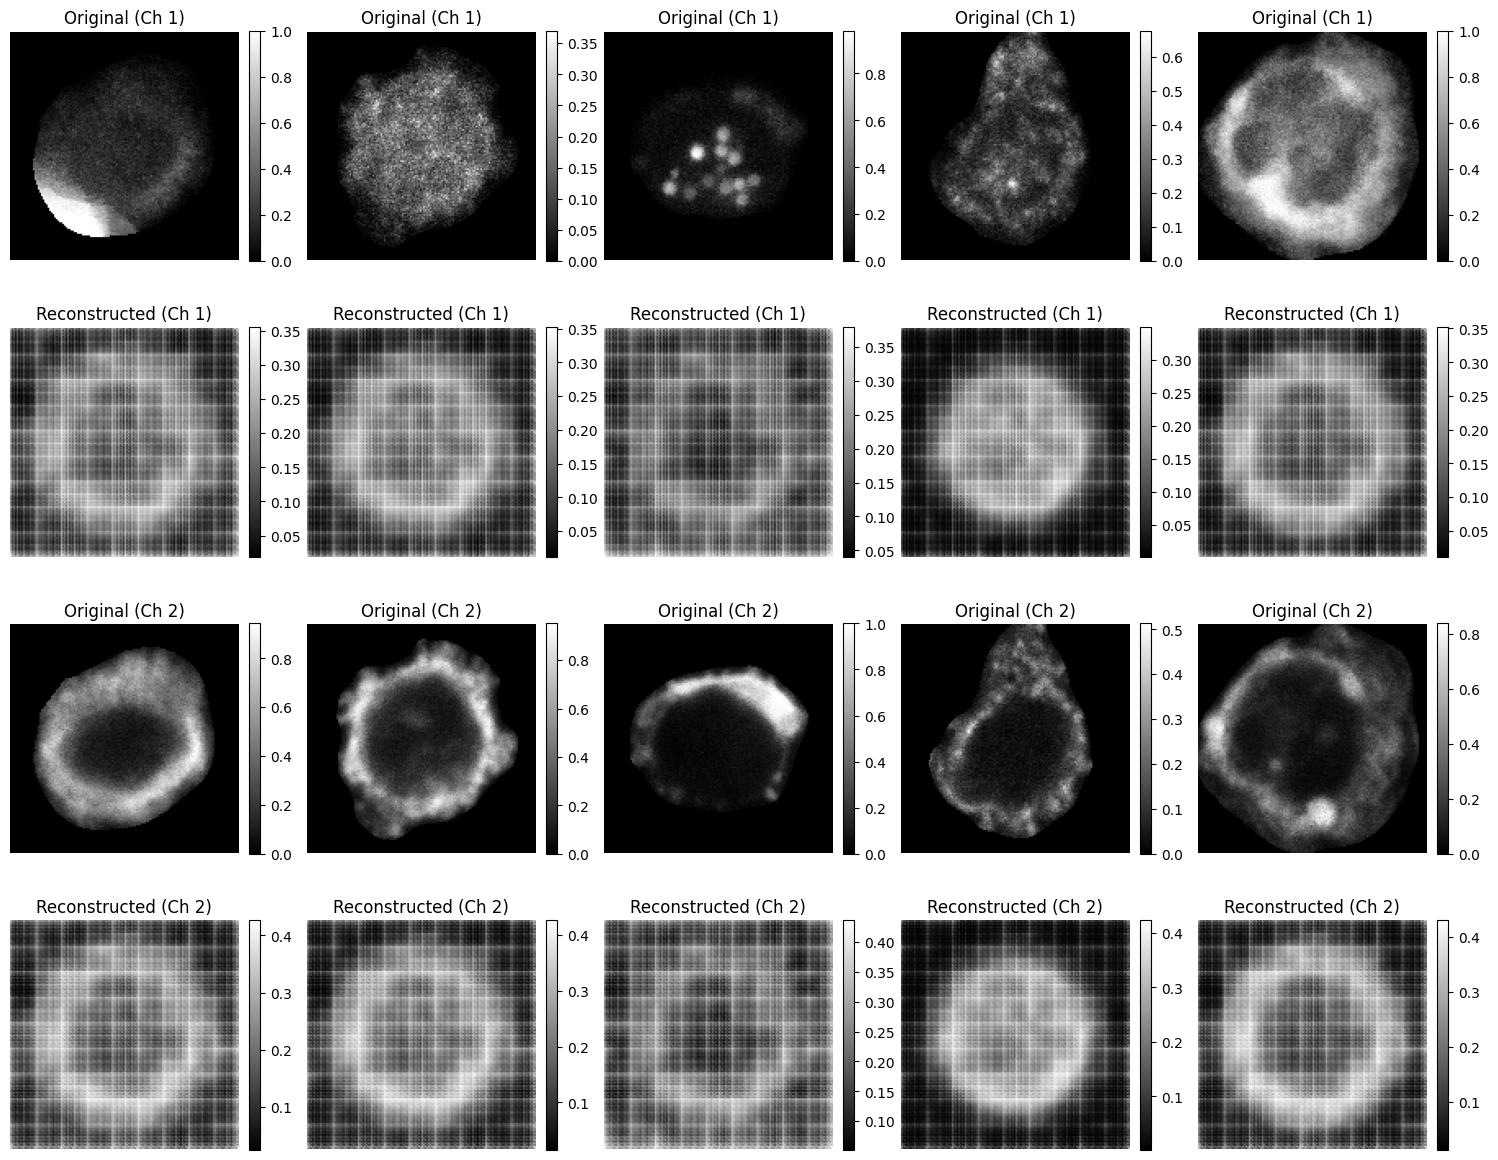

In [19]:
visualize_reconstructions(vae, data_loader, device)

Majority class (0): 1494
Minority class (1): 534
After balancing: Total samples = 1068 (each class: 534)


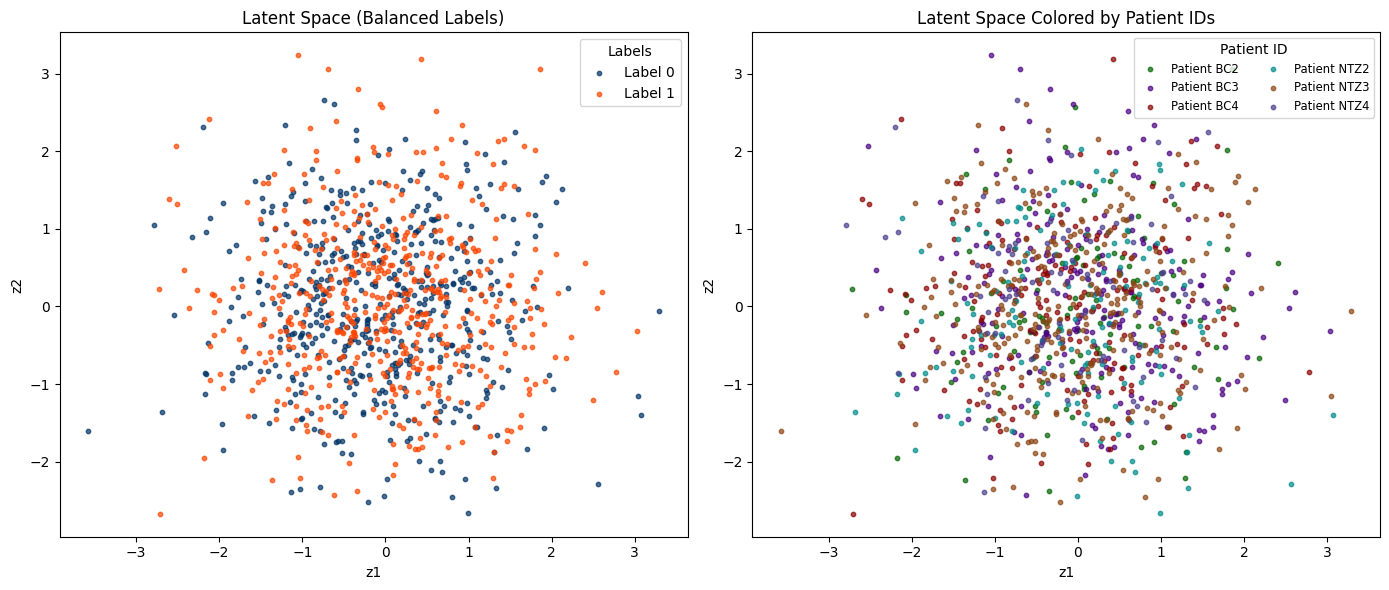

In [20]:
plot_full_latent_space(vae, data_loader, device=device)